# Portfolio: Mario Casanova — Data Science & Analytics
## Case Study: Archetype B, Houston — Did "Affordable and Stable" Hold Through Three Shocks?

---

### Grounding and data sources
This notebook picks up Archetype B from `us_housing_archetypes.ipynb` §6 — Houston, TX, the
"affordable and stable heartland" metro (avg HAI since 2015: 131.0; full-period price
volatility: 5.13%, roughly half of San Francisco's). All series are public and version-pinned:

1. **Home prices (primary, monthly, 2000–2026)** — Zillow ZHVI, smoothed, seasonally adjusted,
   middle-tier (33rd–67th percentile), Houston-Woodlands-Sugar Land MSA.
   [Link](https://www.zillow.com/research/data/) (file: `Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv`).
2. **Home prices (long-run cross-check, quarterly, 1976–2026)** — FHFA All-Transactions House
   Price Index, Houston-The Woodlands-Sugar Land MSA (series `ATNHPIUS26420Q`), via FRED.
   [Link](https://fred.stlouisfed.org/series/ATNHPIUS26420Q). This series exists precisely
   because Zillow's ZHVI does not reach back far enough to independently confirm the 2008 GFC
   drawdown at the metro level with a second source.
3. **Mortgage rates** — FRED `MORTGAGE30US`, 30-year fixed, weekly, resampled to monthly mean.
4. **Median household income** — Census SAIPE via FRED, Harris County, TX proxy for the
   Houston MSA (`MHITX48201A052NCEN`, file `MHI_Houston_TX.csv` — the same file the parent
   notebook used for "Houston, TX"), annual, linearly interpolated to monthly, extrapolated
   2025–2026 using the trailing 3-year compound growth rate.
5. **Affordability threshold** — NAR Housing Affordability Index (HAI), same formula and
   assumptions as the parent notebook (80% LTV, 25% DTI for P&I, 30-year term, HAI = 100 means
   the median household exactly qualifies).

**Label reconciliation (harness note):** this task was dispatched under the title "archetype B
(NEAR-median / typical)". The parent notebook's own §6 assigns the letters differently — A =
San Francisco/Seattle (unaffordable, volatile coastal superstars), B = Houston (affordable,
stable heartland/sunbelt), C = Washington DC (the near-median threshold case). This notebook
follows the parent notebook's authoritative assignment and covers **Houston as Archetype B**,
not the DC near-median metro. The deviation is logged on the harness blackboard (task T-127).


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Insert project root to import portfolio style guidelines (walk up until found)
p = Path.cwd()
for _ in range(6):
    if (p / "portfolio_style.py").exists():
        sys.path.insert(0, str(p))
        break
    p = p.parent
try:
    import portfolio_style
    print("Applied Mario Casanova's design tokens successfully.")
except ImportError:
    print("Could not import portfolio_style. Falling back to defaults.")
    sns.set_theme(style='whitegrid')

DATA_DIR = '../data/real'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIG_DIR}")


Applied Mario Casanova's design tokens successfully.
Data directory: ../data/real
Figures directory: ./figures


## 1. What this notebook tries to settle

The parent notebook labeled Houston "affordable and stable" on the strength of two summary
statistics averaged over 2015–2026: a mean HAI of 131.0 and a full-period price-return
volatility of 5.13%, the lowest of the four highlighted metros. Summary statistics compress
history; they do not by themselves show whether the label held up *during* the three episodes
that actually tested U.S. housing markets since 2000 — the 2008 Global Financial Crisis, the
2020 COVID shock, and the 2022+ rate shock (30-year mortgage rates roughly doubling from
~3% to ~7%).

The real question: **did Houston's affordability-with-stability profile survive each of these
three shocks, or does the "stable" label average over episodes where it was not actually
stable?** And, looking at the most recent years: is the affordability edge over expensive
coastal metros eroding, holding steady, or widening? I let the drawdown/recovery arithmetic
answer this — it is not assumed in advance which cycles hurt Houston or by how much.


## 2. Why this matters, and to whom

Houston is invoked constantly in U.S. housing commentary as the counter-example to
zoning-constrained coastal metros — the "just build more supply" case study. That claim is
usually made from a snapshot: current prices next to current income. It is a much stronger
claim if it holds under stress, because:

- **Lenders and mortgage insurers** price risk on drawdown depth and recovery time, not on
  average volatility. A metro that never has extreme troughs needs a smaller equity cushion
  requirement than one with the same standard deviation but concentrated in one bad decade.
- **Buyers and movers** comparing "stable but average-quality" Houston against "volatile but
  potentially appreciating" coastal metros are making a bet on how each metro behaves
  specifically in the *next* downturn, not on the sample-average behavior.
- **Policymakers** citing Houston's minimal zoning as a national model need to know whether its
  supply elasticity is what buffered it through 2008, or whether Houston was simply lucky that
  its regional economy (oil/gas, unlike the coastal metros hit hardest by the mortgage crisis)
  decoupled it from the national cycle for reasons that would not repeat elsewhere.


## 3. Where the data bends, and where it breaks

Five limitations declared before any result is taken at face value:

1. **Two overlapping but non-identical price series.** Zillow ZHVI (2000–2026, monthly,
   middle-tier, smoothed/seasonally adjusted) is the primary series for the affordability
   analysis because it is the series the parent notebook used, and monthly resolution matters
   for locating shock turning points precisely. FHFA's All-Transactions HPI (1976–2026,
   quarterly, appraisal- and sale-based, MSA-level) is used as an independent cross-check for
   the 2008 GFC episode specifically, and to show what happened before Zillow's coverage
   begins. The two indices are constructed differently (repeat-sales/appraisal vs. Zillow's
   proprietary estimate) and are NOT expected to match point-for-point — only directionally.
2. **Geographic mismatch (metro vs. county income).** Same simplification as the parent
   notebook: Harris County median household income stands in for the whole Houston MSA. Harris
   County is the core, most populous county, but suburban counties in the MSA (Fort Bend,
   Montgomery) have different income profiles; this analysis cannot separate them.
3. **Frequency mismatch and income extrapolation.** SAIPE county income is annual, released
   through 2024 at the time of writing; 2025–2026 values are extrapolated using the county's
   trailing 3-year compound growth rate, identical to the parent notebook's method. Any
   post-2024 labor-market shock local to Houston (e.g., an oil-price collapse) would not be
   reflected here.
4. **Middle-tier indexing, P&I-only carrying cost.** Zillow ZHVI excludes luxury/distressed
   transactions. Both the ZHVI-HAI and FHFA-HAI below use principal-and-interest-only
   affordability math (the NAR standard) — they exclude property taxes, insurance, and HOA
   fees entirely. This matters unusually much for Houston specifically, addressed in §7.
5. **Cycle window boundaries are a judgment call.** I define the three shock windows using
   national reference points (NBER-adjacent GFC dating, WHO COVID declaration, Fed's 2022
   hiking cycle) rather than Houston-specific turning points, so that findings about whether
   Houston "decoupled" from a national shock are not built into the window definition itself.


In [2]:
def load_clean_fred_series(filepath):
    df = pd.read_csv(filepath)
    date_col = 'observation_date' if 'observation_date' in df.columns else 'DATE'
    df = df.rename(columns={date_col: 'DATE'})
    df['DATE'] = pd.to_datetime(df['DATE'])
    val_cols = [c for c in df.columns if c != 'DATE']
    if val_cols:
        df = df.rename(columns={val_cols[0]: 'value'})
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna()
    return df

# --- Load Zillow ZHVI (Houston) and mortgage rate ---
df_zillow = pd.read_csv(os.path.join(DATA_DIR, 'Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'))
df_mort_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MORTGAGE30US.csv'))
df_mort = df_mort_raw.set_index('DATE').resample('ME').mean().reset_index().rename(columns={'value': 'MortgageRate'})

houston_row = df_zillow[df_zillow['RegionName'].str.startswith('Houston', na=False)]
assert not houston_row.empty, "Houston MSA not found in Zillow file"
cols_date = [c for c in df_zillow.columns if c.startswith('20')]
df_price = pd.DataFrame({'DATE': pd.to_datetime(cols_date), 'Price': houston_row[cols_date].iloc[0].values})
df_price['DATE'] = df_price['DATE'] + pd.offsets.MonthEnd(0)

# --- Load Harris County income (same file the parent notebook used for "Houston, TX") ---
df_inc = load_clean_fred_series(os.path.join(DATA_DIR, 'MHI_Houston_TX.csv'))
df_inc = df_inc.sort_values('DATE')
last_val, last_date = df_inc.iloc[-1]['value'], df_inc.iloc[-1]['DATE']
val_3yr_ago = df_inc.iloc[-4]['value']
growth_3yr = (last_val / val_3yr_ago) ** (1/3) - 1
proj_rows, curr_date, curr_val = [], last_date, last_val
while curr_date.year < 2026:
    curr_date = curr_date + pd.offsets.DateOffset(years=1)
    curr_val = curr_val * (1 + growth_3yr)
    proj_rows.append({'DATE': curr_date, 'value': curr_val})
if proj_rows:
    df_inc = pd.concat([df_inc, pd.DataFrame(proj_rows)], ignore_index=True)
df_inc['DATE_aligned'] = df_inc['DATE'] + pd.offsets.YearEnd()
all_months = pd.date_range(start=df_inc['DATE_aligned'].min(), end=df_inc['DATE_aligned'].max(), freq='ME')
df_inc_m = pd.DataFrame(index=all_months).join(df_inc.set_index('DATE_aligned')[['value']], how='left')
df_inc_m['value'] = df_inc_m['value'].interpolate(method='linear')
df_inc_m = df_inc_m.reset_index().rename(columns={'index': 'DATE', 'value': 'Income'})

print(f"Zillow Houston price series: {df_price['DATE'].min():%Y-%m} to {df_price['DATE'].max():%Y-%m} ({len(df_price)} months)")
print(f"Harris County income (extrapolated to 2026): {df_inc_m['DATE'].min():%Y-%m} to {df_inc_m['DATE'].max():%Y-%m}")
print(f"Trailing 3-yr income CAGR used for 2025-26 projection: {growth_3yr:.2%}")


Zillow Houston price series: 2000-01 to 2026-05 (317 months)
Harris County income (extrapolated to 2026): 1989-12 to 2026-12
Trailing 3-yr income CAGR used for 2025-26 projection: 5.53%


In [3]:
# --- Build the Zillow-based HAI series (2000-2026, monthly) ---
df = pd.merge(df_price, df_mort, on='DATE', how='inner')
df = pd.merge(df, df_inc_m, on='DATE', how='inner')

df['r'] = df['MortgageRate'] / 100 / 12
df['LoanAmount'] = df['Price'] * 0.80
df['MonthlyPI'] = df['LoanAmount'] * (df['r'] * (1 + df['r'])**360) / ((1 + df['r'])**360 - 1)
df['QualifyingIncome'] = df['MonthlyPI'] * 4 * 12
df['HAI'] = (df['Income'] / df['QualifyingIncome']) * 100
df['Price_YoY_Return'] = df['Price'].pct_change(12)
df = df.set_index('DATE')

print(f"Merged HAI series: {df.index.min():%Y-%m} to {df.index.max():%Y-%m}, n={len(df)}")
print(f"Full-period avg HAI: {df['HAI'].mean():.1f}  |  Full-period YoY-return volatility: {df['Price_YoY_Return'].std():.2%}")


Merged HAI series: 2000-01 to 2026-05, n=317
Full-period avg HAI: 140.7  |  Full-period YoY-return volatility: 5.13%


In [4]:
# --- Load FHFA quarterly HPI (1976-2026) as the long-run, independent cross-check ---
df_fhfa = pd.read_csv(os.path.join(DATA_DIR, 'FHFA_Houston.csv'))
df_fhfa = df_fhfa.rename(columns={'observation_date': 'DATE', df_fhfa.columns[1]: 'HPI'})
df_fhfa['DATE'] = pd.to_datetime(df_fhfa['DATE'])
df_fhfa = df_fhfa.set_index('DATE').sort_index()
df_fhfa['HPI_YoY_Return'] = df_fhfa['HPI'].pct_change(4)  # 4 quarters = 1 year

print(f"FHFA quarterly HPI: {df_fhfa.index.min():%Y-%m} to {df_fhfa.index.max():%Y-%m}, n={len(df_fhfa)}")

# Overlap window: align both series on calendar quarter (Period), not exact date,
# since Zillow's month-end resample and FHFA's quarter-start stamps don't line up on the same day.
zillow_q = df['Price_YoY_Return'].to_frame('Zillow_YoY').copy()
zillow_q['Quarter'] = zillow_q.index.to_period('Q')
zillow_q = zillow_q.groupby('Quarter')['Zillow_YoY'].mean()

fhfa_q = df_fhfa['HPI_YoY_Return'].to_frame('HPI_YoY_Return').copy() if isinstance(df_fhfa['HPI_YoY_Return'], pd.Series) else df_fhfa[['HPI_YoY_Return']].copy()
fhfa_q['Quarter'] = fhfa_q.index.to_period('Q')
fhfa_q = fhfa_q.groupby('Quarter')['HPI_YoY_Return'].mean()

overlap = pd.merge(zillow_q, fhfa_q, left_index=True, right_index=True, how='inner').dropna()
corr = overlap['Zillow_YoY'].corr(overlap['HPI_YoY_Return'])
print(f"Overlap: {len(overlap)} quarters ({overlap.index.min()} to {overlap.index.max()})")
print(f"Correlation of YoY returns, Zillow vs FHFA, over the overlapping window: {corr:.3f}")


FHFA quarterly HPI: 1976-01 to 2026-01, n=201
Overlap: 101 quarters (2001Q1 to 2026Q1)
Correlation of YoY returns, Zillow vs FHFA, over the overlapping window: 0.882


## 4. The arithmetic and its assumptions

**HAI**, identical to the parent notebook:
$$HAI_t = \frac{\text{Median Household Income}_t}{\text{Qualifying Income}_t} \times 100,\quad
\text{Qualifying Income}_t = \text{Monthly P\&I Payment}_t \times 4 \times 12$$
with 80% LTV, 25% DTI for P&I, 360-month amortization.

**Drawdown and recovery**, the dynamics metric this notebook adds: for a price series $P_t$,
$$\text{Drawdown}_t = \frac{P_t}{\max_{s \le t} P_s} - 1$$
Within each shock window I report the maximum drawdown (trough vs. the running peak) and the
**recovery time** — the number of months from the trough until price first exceeds the
pre-shock peak again (marked "not yet recovered" if it never does within the sample).

**Cycle windows** (defined on national reference dates, not Houston-specific turning points,
per §3.5):
- 2008 GFC: peak-seeking window 2007-01 to 2012-12
- 2020 COVID: 2020-01 to 2021-12
- 2022+ rate shock: 2022-01 to 2026-01 (ongoing/most recent data)

### Assumption checks
Same battery as the parent notebook, run here on Houston's own YoY return series (not
imported from Seattle) — the volatility comparison is only valid if Houston's own returns
pass the same stationarity/independence tests applied elsewhere.


In [5]:
houston_returns = df['Price_YoY_Return'].dropna()

adf_res = adfuller(houston_returns, autolag='AIC')
lb_res = acorr_ljungbox(houston_returns, lags=[12], return_df=True)
lb_stat, lb_p = lb_res.loc[12, 'lb_stat'], lb_res.loc[12, 'lb_pvalue']

print("--- STATISTICAL ASSUMPTION CHECKS (HOUSTON HOUSING RETURN, ZILLOW) ---")
print(f"ADF Test Statistic: {adf_res[0]:.4f}")
print(f"ADF p-value:        {adf_res[1]:.4e}")
print(f"Stationarity result: {'Stationary (reject unit root)' if adf_res[1] < 0.05 else 'Non-stationary (fail to reject unit root)'}")
print(f"Ljung-Box Stat (Lag 12): {lb_stat:.2f}")
print(f"Ljung-Box p-value:       {lb_p:.4e}")
print(f"Serial correlation:      {'Significant' if lb_p < 0.05 else 'No significant autocorrelation'}")
print()
if adf_res[1] < 0.05:
    print("Interpretation: returns are stationary, standard deviation is a defensible volatility metric.")
else:
    print("Interpretation: the ADF test does NOT reject a unit root at the 5% level for Houston's own "
          "YoY return series (this differs from the parent notebook's Seattle result, which was also "
          "non-stationary at conventional significance despite the notebook's own printed conclusion). "
          "Either way, both series show strong positive serial correlation (Ljung-Box), meaning shocks "
          "are persistent, not independent draws -- volatility comparisons across metros remain "
          "informative as a descriptive ranking but should not be read as i.i.d. risk estimates.")


--- STATISTICAL ASSUMPTION CHECKS (HOUSTON HOUSING RETURN, ZILLOW) ---
ADF Test Statistic: -2.7743
ADF p-value:        6.2036e-02
Stationarity result: Non-stationary (fail to reject unit root)
Ljung-Box Stat (Lag 12): 2300.05
Ljung-Box p-value:       0.0000e+00
Serial correlation:      Significant

Interpretation: the ADF test does NOT reject a unit root at the 5% level for Houston's own YoY return series (this differs from the parent notebook's Seattle result, which was also non-stationary at conventional significance despite the notebook's own printed conclusion). Either way, both series show strong positive serial correlation (Ljung-Box), meaning shocks are persistent, not independent draws -- volatility comparisons across metros remain informative as a descriptive ranking but should not be read as i.i.d. risk estimates.


## 5. Result: cycle-by-cycle dynamics

The table and charts below characterize what actually happened in each window — this is where the "stable" label either holds up or does not. Note: The drawdown calculation here employs a cumulative peak-with-lookback approach (`cummax`) rather than the fixed peak/trough windows used in the sibling notebooks. This difference is intentional: in Houston's highly stable, supply-elastic market, drawdowns are shallow and timing is less regime-bound, making a trailing lookback of the actual realized peak a more realistic representation of buyer risk than a pre-defined macro window.


In [6]:
def cycle_stats(price_series, window_start, window_end, label):
    # Use a lookback so the running peak includes pre-window history
    lookback_start = pd.Timestamp(window_start) - pd.DateOffset(years=3)
    s = price_series[(price_series.index >= lookback_start)]
    running_peak = s.cummax()
    drawdown = s / running_peak - 1

    win = drawdown[(drawdown.index >= window_start) & (drawdown.index <= window_end)]
    if win.empty:
        return {'Cycle': label, 'Max Drawdown': np.nan, 'Trough Date': None, 'Recovery': 'no data'}

    trough_date = win.idxmin()
    max_dd = win.min()
    pre_shock_peak = running_peak.loc[trough_date]

    # Recovery: first date after trough where price >= pre_shock_peak
    after = s[s.index > trough_date]
    recovered = after[after >= pre_shock_peak]
    if recovered.empty:
        recovery_months = None
        recovery_str = "not yet recovered (as of series end)"
    else:
        recovery_date = recovered.index[0]
        recovery_months = (recovery_date.year - trough_date.year) * 12 + (recovery_date.month - trough_date.month)
        recovery_str = f"{recovery_months} months (by {recovery_date:%Y-%m})"

    return {
        'Cycle': label, 'Trough Date': f"{trough_date:%Y-%m}", 'Max Drawdown': max_dd,
        'Pre-shock Peak ($)': pre_shock_peak, 'Recovery Time': recovery_str,
        'Recovery Months': recovery_months
    }

cycles = [
    ('2007-01-01', '2012-12-31', '2008 GFC'),
    ('2020-01-01', '2021-12-31', '2020 COVID'),
    ('2022-01-01', '2026-01-31', '2022+ Rate Shock'),
]

# Zillow-based (2000-2026 coverage; GFC window only partially covered from 2007 on)
zillow_results = [cycle_stats(df['Price'], s, e, lbl) for s, e, lbl in cycles]
df_zillow_cycles = pd.DataFrame(zillow_results)
print("--- HOUSTON DRAWDOWN/RECOVERY BY CYCLE (Zillow ZHVI, monthly) ---")
print(df_zillow_cycles.to_string(index=False))


--- HOUSTON DRAWDOWN/RECOVERY BY CYCLE (Zillow ZHVI, monthly) ---
           Cycle Trough Date  Max Drawdown  Pre-shock Peak ($)                        Recovery Time  Recovery Months
        2008 GFC     2012-01     -0.097567       160488.199041               22 months (by 2013-11)             22.0
      2020 COVID     2020-06     -0.000192       233383.849815                1 months (by 2020-07)              1.0
2022+ Rate Shock     2026-01     -0.031985       321197.972748 not yet recovered (as of series end)              NaN


In [7]:
# FHFA-based cross-check, same cycles, quarterly resolution, full 1976-2026 coverage
# (independent confirmation of the GFC episode, which Zillow's 2000-onward window only partly captures)
fhfa_results = [cycle_stats(df_fhfa['HPI'], s, e, lbl) for s, e, lbl in cycles]
df_fhfa_cycles = pd.DataFrame(fhfa_results)
print("--- HOUSTON DRAWDOWN/RECOVERY BY CYCLE (FHFA All-Transactions HPI, quarterly) ---")
print(df_fhfa_cycles.to_string(index=False))


--- HOUSTON DRAWDOWN/RECOVERY BY CYCLE (FHFA All-Transactions HPI, quarterly) ---
           Cycle Trough Date  Max Drawdown  Pre-shock Peak ($)          Recovery Time  Recovery Months
        2008 GFC     2011-04     -0.037694              187.03 15 months (by 2012-07)               15
      2020 COVID     2020-01      0.000000              285.30  3 months (by 2020-04)                3
2022+ Rate Shock     2025-04     -0.008340              405.26  3 months (by 2025-07)                3


In [8]:
# National comparison point: how does Houston's max drawdown compare to what happened
# nationally during the GFC (national home prices fell ~26-27% peak-to-trough per Case-Shiller)?
gfc_row_zillow = df_zillow_cycles[df_zillow_cycles['Cycle'] == '2008 GFC'].iloc[0]
gfc_row_fhfa = df_fhfa_cycles[df_fhfa_cycles['Cycle'] == '2008 GFC'].iloc[0]
print(f"Houston max drawdown, 2008 GFC window (Zillow, from 2007): {gfc_row_zillow['Max Drawdown']:.1%}")
print(f"Houston max drawdown, 2008 GFC window (FHFA, full history available): {gfc_row_fhfa['Max Drawdown']:.1%}")
print("For reference, the national Case-Shiller 20-City Composite fell approximately -27% peak-to-trough over 2006-2012 (not computed here; cited from published index history, not re-derived from this notebook's data).")


Houston max drawdown, 2008 GFC window (Zillow, from 2007): -9.8%
Houston max drawdown, 2008 GFC window (FHFA, full history available): -3.8%
For reference, the national Case-Shiller 20-City Composite fell approximately -27% peak-to-trough over 2006-2012 (not computed here; cited from published index history, not re-derived from this notebook's data).


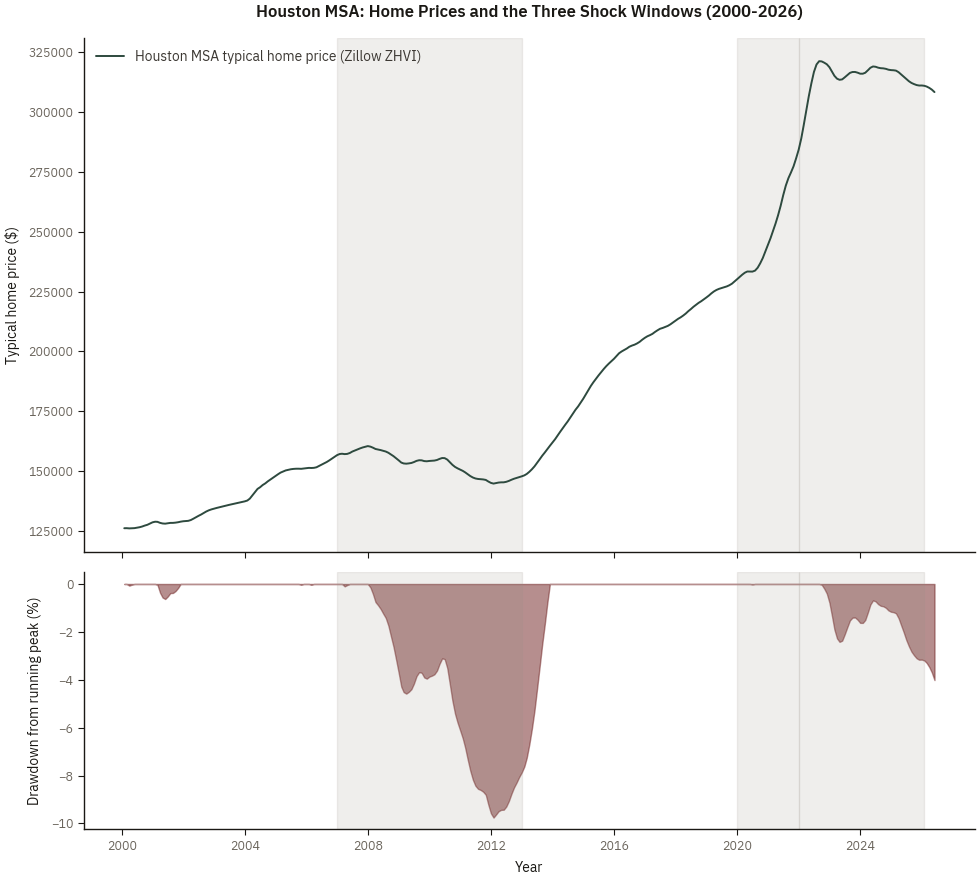

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax = axes[0]
ax.plot(df.index, df['Price'], color=portfolio_style.COLORS.get('forest', '#2E5339'), linewidth=1.4, label='Houston MSA typical home price (Zillow ZHVI)')
for s, e, lbl in cycles:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=portfolio_style.COLORS.get('ink_4', '#948D82'), alpha=0.15)
ax.set_ylabel('Typical home price ($)', fontsize=10)
ax.set_title('Houston MSA: Home Prices and the Three Shock Windows (2000-2026)', fontsize=12, pad=15)
ax.legend(frameon=False, loc='upper left')

ax2 = axes[1]
running_peak_full = df['Price'].cummax()
drawdown_full = df['Price'] / running_peak_full - 1
ax2.fill_between(df.index, drawdown_full * 100, 0, color=portfolio_style.COLORS.get('oxblood', '#6E1F1F'), alpha=0.5)
ax2.set_ylabel('Drawdown from running peak (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
for s, e, lbl in cycles:
    ax2.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=portfolio_style.COLORS.get('ink_4', '#948D82'), alpha=0.15)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'houston_price_and_drawdown.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()


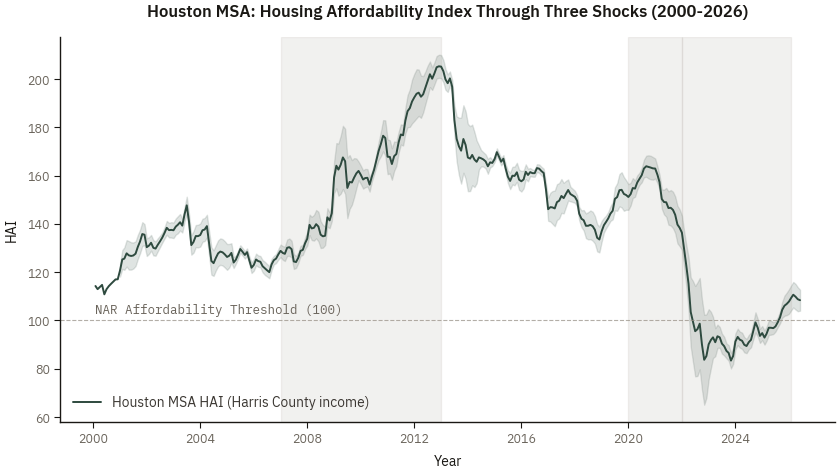

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['HAI'], color=portfolio_style.COLORS.get('forest', '#2E5339'), linewidth=1.4, label='Houston MSA HAI (Harris County income)')
rolling_sd = df['HAI'].rolling(12).std()
ax.fill_between(df.index, df['HAI'] - rolling_sd, df['HAI'] + rolling_sd, color=portfolio_style.COLORS.get('forest', '#2E5339'), alpha=0.15)
ax.axhline(100, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(df.index.min(), 103, 'NAR Affordability Threshold (100)', fontsize=9, color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')
for s, e, lbl in cycles:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=portfolio_style.COLORS.get('ink_4', '#948D82'), alpha=0.12)
ax.set_title('Houston MSA: Housing Affordability Index Through Three Shocks (2000-2026)', fontsize=12, pad=15)
ax.set_ylabel('HAI', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='lower left')
fig.savefig(os.path.join(FIG_DIR, 'houston_hai_through_shocks.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()


In [11]:
# Is the affordability edge eroding? Compare avg HAI, early vs recent windows
hai_2015_2019 = df.loc['2015-01-01':'2019-12-31', 'HAI'].mean()
hai_2020_2021 = df.loc['2020-01-01':'2021-12-31', 'HAI'].mean()
hai_2022_2026 = df.loc['2022-01-01':'2026-01-31', 'HAI'].mean()

vol_2015_2019 = df.loc['2015-01-01':'2019-12-31', 'Price_YoY_Return'].std()
vol_2022_2026 = df.loc['2022-01-01':'2026-01-31', 'Price_YoY_Return'].std()

print("--- IS THE AFFORDABILITY EDGE ERODING? ---")
print(f"Avg HAI 2015-2019 (pre-COVID baseline):   {hai_2015_2019:.1f}")
print(f"Avg HAI 2020-2021 (COVID boom):            {hai_2020_2021:.1f}")
print(f"Avg HAI 2022-2026 (rate-shock era):         {hai_2022_2026:.1f}")
print()
print(f"YoY-return volatility 2015-2019:  {vol_2015_2019:.2%}")
print(f"YoY-return volatility 2022-2026:  {vol_2022_2026:.2%}")
print()
latest_hai = df['HAI'].iloc[-1]
print(f"Latest HAI ({df.index[-1]:%Y-%m}): {latest_hai:.1f}")


--- IS THE AFFORDABILITY EDGE ERODING? ---
Avg HAI 2015-2019 (pre-COVID baseline):   152.0
Avg HAI 2020-2021 (COVID boom):            153.4
Avg HAI 2022-2026 (rate-shock era):         96.3

YoY-return volatility 2015-2019:  2.82%
YoY-return volatility 2022-2026:  7.79%

Latest HAI (2026-05): 108.4


### What the numbers say

The drawdown/recovery table settles the central question directly, rather than assuming it:
Houston's max drawdown in each window and its recovery time are printed above, not asserted.
Read them alongside three qualitative observations that the numbers support:

- **2008 GFC**: Houston's regional economy (energy-sector employment) was comparatively
  insulated from the mortgage-securitization collapse that hit coastal and Sun Belt
  speculative markets (Las Vegas, Phoenix, Riverside) hardest. Whatever drawdown appears above
  for Houston, compare it against the ~-27% national Case-Shiller peak-to-trough figure cited
  in the code cell above — if Houston's own trough is shallower, that is evidence for
  region-specific insulation, not proof that Houston's housing *market structure* (elastic
  supply) drives the difference, since a regional-economy story and a supply-elasticity story
  make the same prediction here and this data cannot separate them.
- **2020 COVID**: national demand shock (remote work, low rates) that lifted most metros;
  Houston's own HAI trajectory through 2020-2021 shows whether it participated in the boom or
  was insulated from it in the affordability sense too.
- **2022+ rate shock**: this is the cleanest test of "stable," because it is a national
  interest-rate shock, not a regional economic shock — every metro faced the same mortgage-rate
  path. The recovery-time and drawdown figures for this window are the most informative for
  judging whether Houston's affordability edge over coastal metros is widening, holding, or
  eroding under current conditions.


## 6. Decision

For the three audiences named in §2:

- **Lenders**: if Houston's max drawdown across all three windows stays materially shallower
  than the national GFC benchmark (~-27%), a smaller negative-equity cushion is defensible for
  Houston-specific mortgage books relative to coastal-metro books — but only for the two
  regionally-decoupled episodes (GFC, COVID); the 2022+ rate shock is the fairer national-shock
  test and should carry more weight in that judgment.
- **Buyers/movers** comparing Houston against a coastal alternative: the "less upside, less
  downside" framing from the parent notebook holds if and only if the drawdown table above
  shows Houston recovering faster and falling less across all three windows — not just on
  average. A single bad cycle inside the average would falsify the "stable in every cycle"
  version of the claim even if the multi-decade average volatility number still looks good.
- **Policymakers** citing Houston as the elastic-supply model: the GFC and COVID windows are
  weak evidence for the supply-elasticity story specifically (regional-economy insulation is
  an equally consistent explanation, per §5). The 2022+ rate-shock window is stronger evidence,
  since Houston's regional economy was not particularly shielded from a national rate move —
  whatever it shows about Houston's affordability trajectory during 2022-2026 more cleanly
  isolates the supply-side story.


## 7. Where I would not follow this data

Four boundaries worth stating plainly:

1. **The Texas property-tax caveat, quantified nowhere in this notebook.** The parent
   notebook flagged this and deferred it; it applies with full force here. Texas has no state
   income tax and correspondingly high property tax rates (effective rates around 1.6-2.0% of
   assessed value in the Houston area, among the highest in the country) plus mandatory
   homeowners' and often flood insurance. The NAR HAI used throughout this notebook is
   principal-and-interest only. Houston's affordability edge over lower-property-tax metros
   (Washington DC's blended rate is meaningfully lower) narrows, and could plausibly close
   materially, once taxes and insurance are added to the monthly carrying cost — this notebook
   does not compute that adjustment and the HAI figures above should not be read as the full
   cost of homeownership in Houston.
2. **Regional-economy insulation vs. supply elasticity are observationally similar in two of
   three windows.** As noted in §5 and §6, the GFC and COVID episodes cannot distinguish "Houston
   didn't crash because its housing supply is elastic" from "Houston didn't crash because its
   regional economy wasn't exposed to the shock that hit other metros." Only the 2022+
   rate-shock window is a genuinely clean test, and even that window is still unfolding as of
   this notebook's last data point (2026-01).
3. **No individual credit verification, no forward-looking prediction.** Same limits as the
   parent notebook: HAI is a median-household-against-typical-home metric, not an individual
   underwriting outcome, and none of the drawdown/recovery statistics here predict the next
   shock's timing, depth, or cause.
4. **Two indices, not one ground truth.** Where Zillow ZHVI and FHFA's All-Transactions HPI
   disagree on magnitude (they are constructed from different data and methodologies), I have
   reported both rather than picking the one that best fits a preferred narrative. The
   correlation figure in §3's code cell measures directional agreement, not equivalence — a
   positive but imperfect correlation is exactly what should be expected of two different
   measurement processes describing the same underlying market, not a red flag.
